# Cook County Ozone Study

Ozone is produced when sunlight photolyzes nitrogen dioxide:

$$
\text{NO}_2 + h\nu \rightarrow \text{NO} + \text{O}
$$

$$
\text{O} + \text{O}_2 + \text{M}
\rightarrow \text{O}_3 + \text{M}
$$

Ozone is removed through reaction with nitric oxide:

$$
\text{NO} + \text{O}_3
\rightarrow \text{NO}_2 + \text{O}_2
$$

By themselves, these reactions form a rapid cycle with little net ozone
production. Net ozone accumulates when radicals produced by the oxidation of
volatile organic compounds (VOCs) and carbon monoxide convert NO back to
NO₂ without consuming ozone. The observed relationship between ozone and NO₂
therefore also depends on VOC concentrations, sunlight, emissions, atmospheric
mixing, and transport.

This notebook compares hourly ozone and nitrogen dioxide measurements at four
EPA Air Quality System (AQS) stations in Cook County, Illinois. Most of the
focus is on the NOrthbrook Water Plant which is the only station which measures
o3, no2, wind, and radiation


## Stations

| Station | AQS station ID |
|---|---:|
| Evanston Water Plant | 17-031-7002 |
| Northbrook Water Plant | 17-031-4201 |
| Cook County Trailer | 17-031-4002 |
| IEPA Trailer | 17-031-3103 |

## Analyses

1. Plot a full-year hourly ozone timeseries for all four stations.
2. Plot paired ozone and NO₂ time-of-day calendar heatmaps for Northbrook,
   the IEPA Trailer, and the Cook County Trailer.
3. Identify the five highest 1-hour ozone days at each station and find dates
   shared among the station-specific top-five lists.
4. Plot ozone and NO₂ together for the three highest 1-hour ozone days at
   each of the three comparison stations.

The analysis year is controlled by `YEAR`, so the notebook can be adapted to
another year by changing one value.

## Dependencies

This notebook uses the repository helpers `aqs_codes.py`, `aqs_utils.py`,
`aqi_colors.py`, `fips_codes.py`, and `plot_time_heatmap_2024.py`.

## License

Copyright (C) 2026 Greg Anderson

This notebook is free software: you can redistribute it and/or modify it under
the terms of the [GNU General Public License v3](LICENSE).


## Imports

In [1]:
import datetime as dt
import importlib
import os
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import pandas as pd
import pyaqsapi as aqs
import pytz
from dotenv import load_dotenv
from IPython.display import display
from matplotlib.patches import Rectangle
from suntime import Sun

import aqs_codes
import aqs_utils
import plot_utils

importlib.reload(aqs_codes)
importlib.reload(plot_utils)
importlib.reload(aqs_utils)

from aqi_colors import aqi_boxes
from aqs_codes import no2, o3
from aqs_utils import download_daily_summary, download_hourly_data, wrangle_aqs_timeseries
from fips_codes import FIPS
from plot_utils import plot_hourly_heatmap, nighttime_boxes

## EPA AQS credentials

The cell below loads an AQS username and key from a `.env` file in the
repository directory:

```text
AQS_USER=your_email@example.com
AQS_KEY=your_aqs_key
```

A free key is available from the
[EPA AQS API](https://aqs.epa.gov/aqsweb/documents/data_api.html).


In [2]:
load_dotenv()

AQS_USER = os.getenv("AQS_USER")
AQS_KEY = os.getenv("AQS_KEY")

if not AQS_USER or not AQS_KEY:
    raise RuntimeError(
        "Missing EPA AQS credentials. Create a .env file containing:\n"
        "AQS_USER=your_email@example.com\n"
        "AQS_KEY=your_aqs_key"
    )

aqs.aqs_credentials(username=AQS_USER, key=AQS_KEY)

## Study configuration

In [3]:
YEAR = 2024

START_DT = dt.datetime(YEAR, 1, 1)
END_DT = dt.datetime(YEAR, 12, 31, 23, 59)
    
# January 1 of the following year is the right edge of annual plots.
PLOT_END_DT = dt.datetime(YEAR + 1, 1, 1)

FIGURE_DIR = Path("figures") / "aqs"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

OZONE_COLOR = "#5B9BD5"   # soft medium blue
NO2_COLOR = "#A0522D"     # reddish brown / sienna

STATE_FIPS = FIPS.IL.fips
COUNTY_FIPS = FIPS.IL.Cook
CHICAGO_TIME = pytz.timezone("America/Chicago")

STATIONS = {
    "Evanston": {
        "name": "Evanston Water Plant",
        "site_number": "7002",
    },
    "Northbrook": {
        "name": "Northbrook Water Plant",
        "site_number": "4201",
    },
    "Cook County Trailer": {
        "name": "Cook County Trailer",
        "site_number": "4002",
    },
    "IEPA Trailer": {
        "name": "IEPA Trailer",
        "site_number": "3103",
    },
}

for station in STATIONS.values():
    station["station_id"] = (
        f"{STATE_FIPS}-{COUNTY_FIPS}-{station['site_number']}"
    )

HEATMAP_STATIONS = [
    "Northbrook",
    "IEPA Trailer",
    "Cook County Trailer",
]

EVENT_STATIONS = HEATMAP_STATIONS.copy()

STATIONS

{'Evanston': {'name': 'Evanston Water Plant',
  'site_number': '7002',
  'station_id': '17-031-7002'},
 'Northbrook': {'name': 'Northbrook Water Plant',
  'site_number': '4201',
  'station_id': '17-031-4201'},
 'Cook County Trailer': {'name': 'Cook County Trailer',
  'site_number': '4002',
  'station_id': '17-031-4002'},
 'IEPA Trailer': {'name': 'IEPA Trailer',
  'site_number': '3103',
  'station_id': '17-031-3103'}}

## Download and wrangle hourly data

`aqs.bysite.sampledata()` returns the individual measurements reported by one
station. The repository function `wrangle_aqs_timeseries()` creates local and
GMT datetime columns. The small wrapper below supplies the station metadata,
keeps 1-hour samples, and sorts the observations by local time.


In [4]:
def save_figure(fig, filename, dpi=300):
    """Save a Matplotlib figure in the AQS figures directory."""
    output_path = FIGURE_DIR / filename

    fig.savefig(
        output_path,
        dpi=dpi,
        bbox_inches="tight",
    )

    print(f"Saved {output_path}")
    

def filename_slug(text):
    """Convert a station name to a filename-friendly string."""
    return (
        text.lower()
        .replace("—", " ")
        .replace("-", " ")
        .replace("/", " ")
        .replace(" ", "_")
    )    
    
def hourly_data(station_key, parameter):
    """Notebook wrapper: supply the study's fixed AQS parameters."""
    return download_hourly_data(
        station_key, parameter, STATIONS,
        STATE_FIPS, COUNTY_FIPS, START_DT, END_DT, aqs, year=YEAR,
    )    

In [5]:
# Ozone is needed at all four stations.
ozone_hourly = {}

for station_key in STATIONS:
    station_name = STATIONS[station_key]["name"]
    print(f"Downloading {o3.name}: {station_name}")
    ozone_hourly[station_key] = hourly_data(station_key, o3)

In [6]:
# Nitrogen dioxide is needed at the three heatmap/event stations.
nitrogen_dioxide_hourly = {}

for station_key in HEATMAP_STATIONS:
    station_name = STATIONS[station_key]["name"]
    print(f"Downloading {no2.name}: {station_name}")
    nitrogen_dioxide_hourly[station_key] = hourly_data(station_key, no2)

### Data coverage summary

In [7]:
coverage_rows = []

for station_key, data in ozone_hourly.items():
    coverage_rows.append(
        {
            "station": STATIONS[station_key]["name"],
            "pollutant": o3.symbol,
            "measurements": len(data),
            "first_measurement": data["datetime_local"].min(),
            "last_measurement": data["datetime_local"].max(),
        }
    )

for station_key, data in nitrogen_dioxide_hourly.items():
    coverage_rows.append(
        {
            "station": STATIONS[station_key]["name"],
            "pollutant": no2.symbol,
            "measurements": len(data),
            "first_measurement": data["datetime_local"].min(),
            "last_measurement": data["datetime_local"].max(),
        }
    )

coverage = pd.DataFrame(coverage_rows)
display(coverage)


,station,pollutant,measurements,first_measurement,last_measurement
0,Evanston Water Plant,O₃,5880,2024-03-01,2024-10-31 23:00:00
1,Northbrook Water Plant,O₃,8784,2024-01-01,2024-12-31 23:00:00
2,Cook County Trailer,O₃,5880,2024-03-01,2024-10-31 23:00:00
3,IEPA Trailer,O₃,5880,2024-03-01,2024-10-31 23:00:00
4,Northbrook Water Plant,NO₂,2208,2024-06-01,2024-08-31 23:00:00
5,IEPA Trailer,NO₂,8784,2024-01-01,2024-12-31 23:00:00
6,Cook County Trailer,NO₂,8784,2024-01-01,2024-12-31 23:00:00


## 1. Full-year hourly ozone timeseries

The four panels use the same vertical scale so concentrations can be compared
directly. The colored background uses the repository's ozone AQI bands.

The plotted measurements are hourly samples. The AQI background uses the
current 8-hour ozone categories only as concentration context.

Saved figures/aqs/aqs_hourly_ozone_timeseries_cook_2024.png


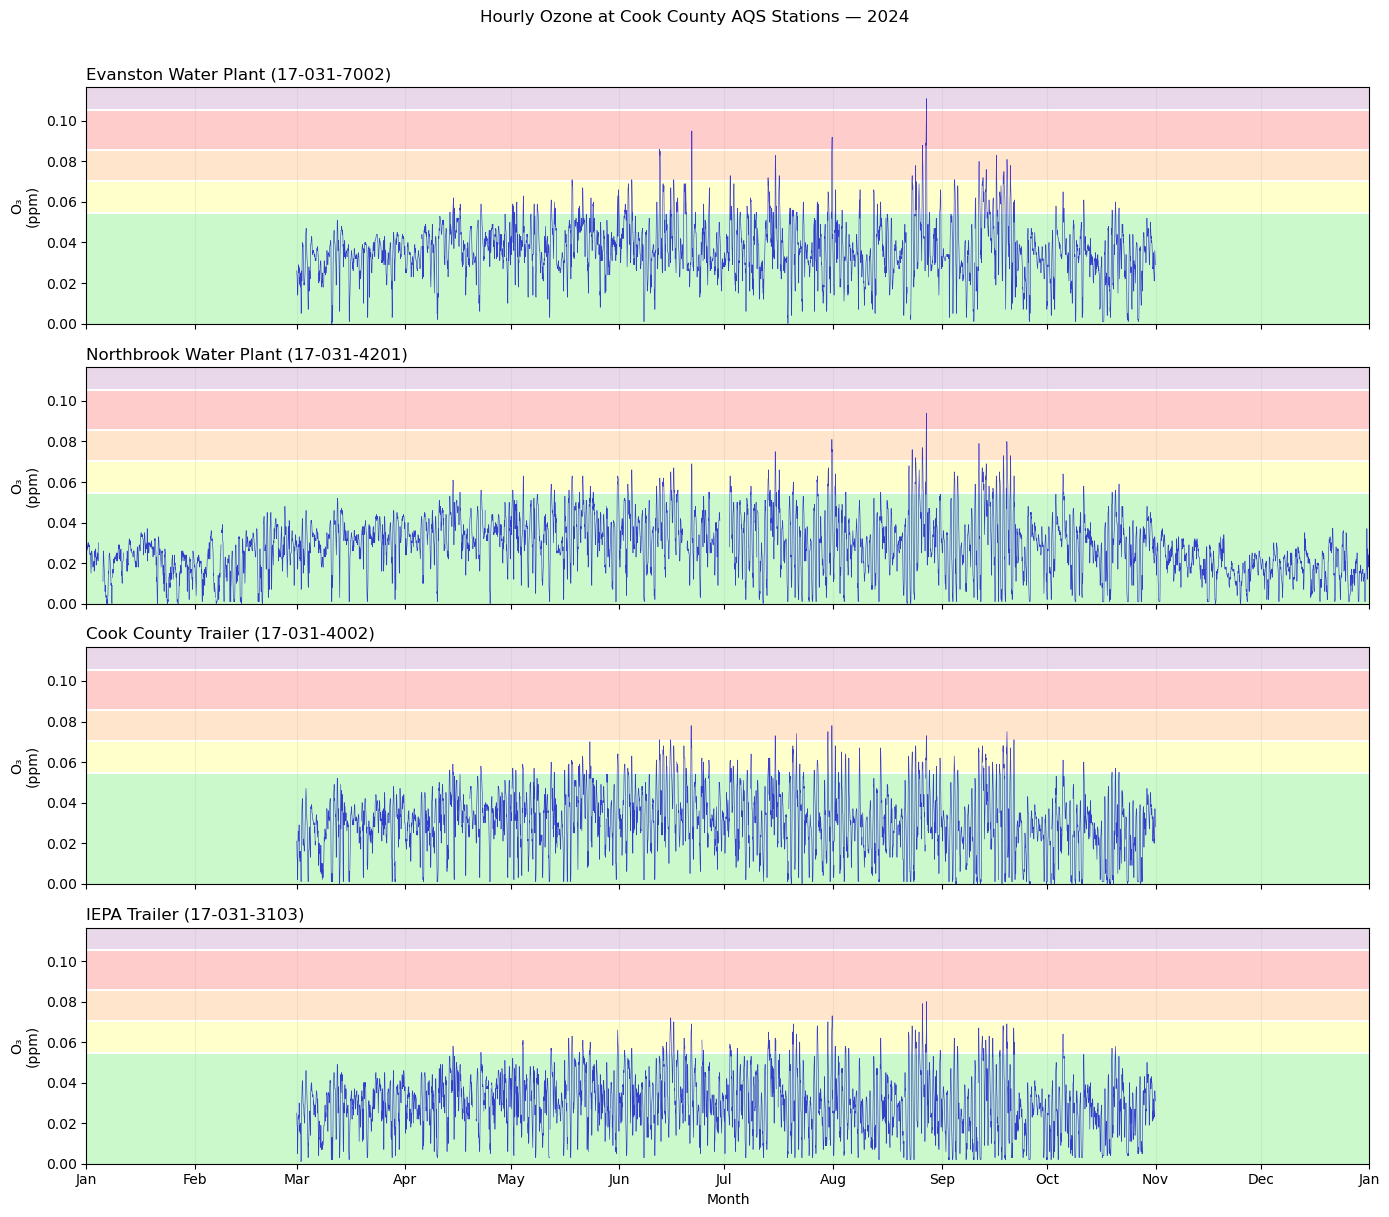

In [8]:
observed_ozone_max = max(
    data["sample_measurement"].max()
    for data in ozone_hourly.values()
)
ozone_y_max = 1.05 * observed_ozone_max

fig, axes = plt.subplots(
    nrows=len(STATIONS),
    ncols=1,
    figsize=(14, 12),
    sharex=True,
    sharey=True,
)

for ax, (station_key, station) in zip(axes, STATIONS.items()):
    data = ozone_hourly[station_key]

    for box in aqi_boxes(
        "o3_8hr",
        START_DT,
        PLOT_END_DT,
        ozone_y_max,
    ):
        ax.add_patch(box)

    ax.plot(
        data["datetime_local"],
        data["sample_measurement"],
        linewidth=0.45,
        color="mediumblue",
        alpha=0.75,
    )

    ax.set_xlim(START_DT, PLOT_END_DT)
    ax.set_ylim(0, ozone_y_max)
    ax.set_ylabel(f"{o3.symbol}\n({o3.units})")
    ax.set_title(
        f"{station['name']} ({station['station_id']})",
        loc="left",
    )
    ax.grid(axis="x", alpha=0.2)

axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%b"))
axes[-1].set_xlabel("Month")

fig.suptitle(f"Hourly Ozone at Cook County AQS Stations — {YEAR}", y=1.01)
fig.tight_layout()
save_figure(
    fig,
    f"aqs_hourly_ozone_timeseries_cook_{YEAR}.png",
)

plt.show()

## 2. Paired ozone and NO₂ calendar heatmaps

Each station has two vertically stacked heatmaps. Columns represent day of year
and rows represent local hour.

AQI categories are too coarse for these data, so the heatmaps use continuous
concentration scales. A common scale is used for each pollutant across all
three stations. The upper limit is the 99th percentile of the combined hourly
measurements, which preserves detail without allowing a few extreme values to
control the full color range. Values above that limit use the highest color.


Ozone heatmap scale: 0.000 to 0.065 ppm
NO2 heatmap scale: 0.0 to 45.3 ppb
Saved figures/aqs/aqs_ozone_no2_heatmap_cook_northbrook_water_plant_2024.png


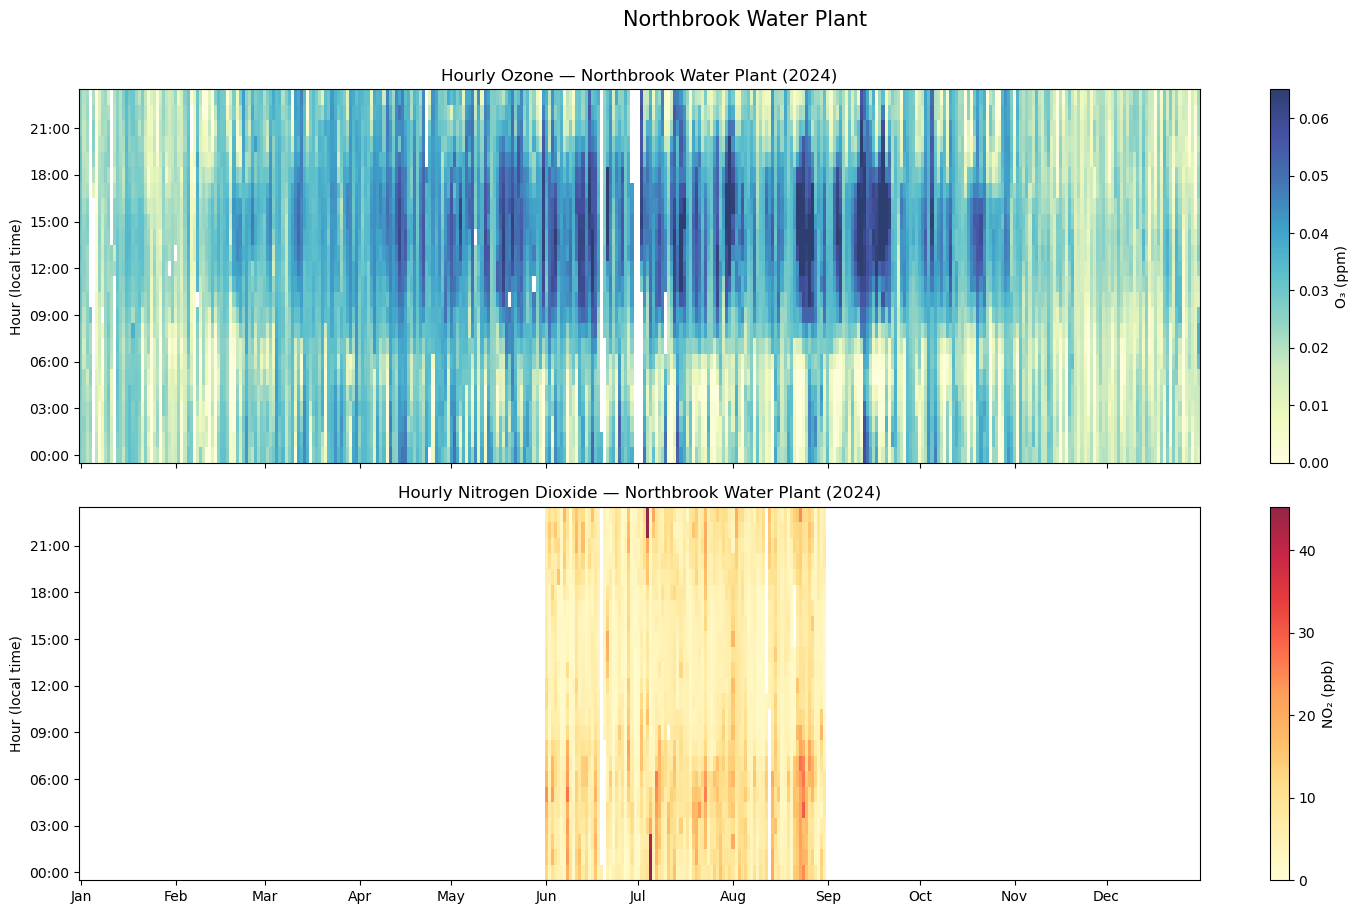

Saved figures/aqs/aqs_ozone_no2_heatmap_cook_iepa_trailer_2024.png


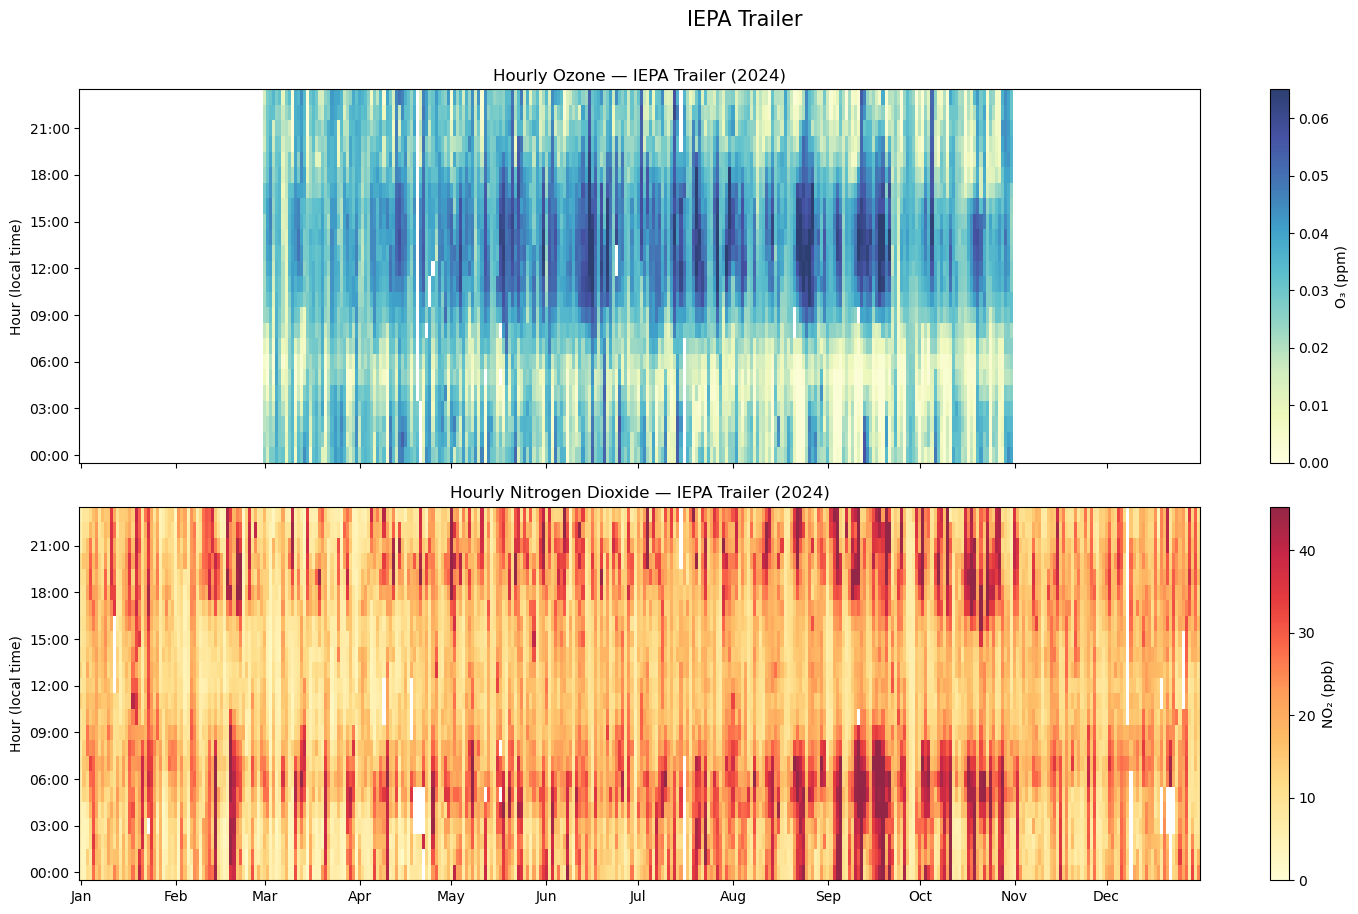

Saved figures/aqs/aqs_ozone_no2_heatmap_cook_cook_county_trailer_2024.png


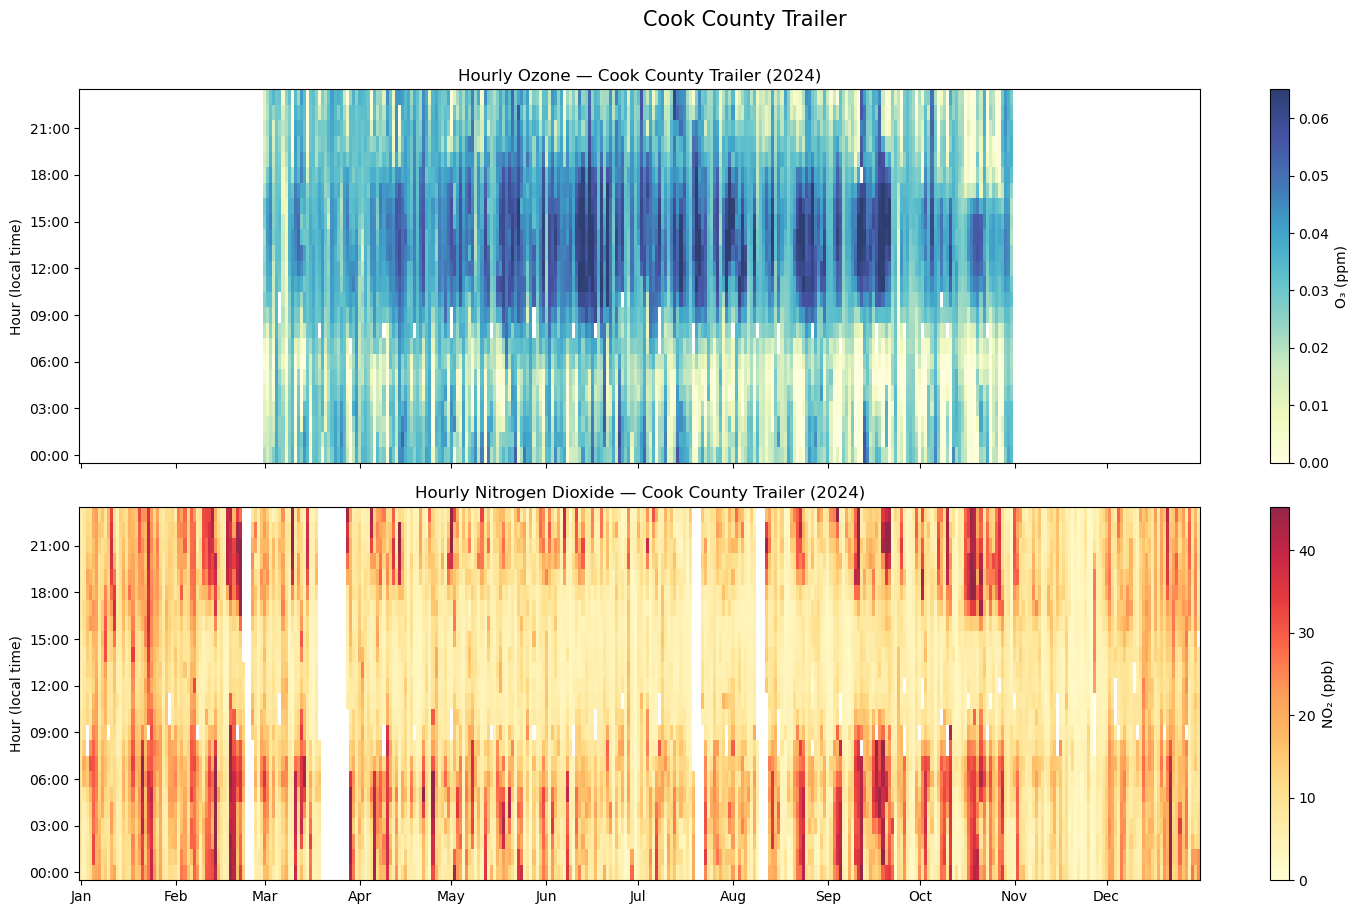

In [9]:
ozone_heatmap_values = pd.concat(
    [
        ozone_hourly[station_key]["sample_measurement"]
        for station_key in HEATMAP_STATIONS
    ],
    ignore_index=True,
)

no2_heatmap_values = pd.concat(
    [
        nitrogen_dioxide_hourly[station_key]["sample_measurement"]
        for station_key in HEATMAP_STATIONS
    ],
    ignore_index=True,
)

OZONE_HEATMAP_MIN = 0
OZONE_HEATMAP_MAX = ozone_heatmap_values.quantile(0.99)

NO2_HEATMAP_MIN = 0
NO2_HEATMAP_MAX = no2_heatmap_values.quantile(0.99)

print(
    f"Ozone heatmap scale: {OZONE_HEATMAP_MIN:.3f} to "
    f"{OZONE_HEATMAP_MAX:.3f} {o3.units}"
)
print(
    f"NO2 heatmap scale: {NO2_HEATMAP_MIN:.1f} to "
    f"{NO2_HEATMAP_MAX:.1f} {no2.units}"
)

for station_key in HEATMAP_STATIONS:
    station_name = STATIONS[station_key]["name"]

    fig, axes = plt.subplots(
        nrows=2,
        ncols=1,
        figsize=(15, 9),
        sharex=True,
    )

    plot_hourly_heatmap(
        data=ozone_hourly[station_key],
        datetime_col="datetime_local",
        value_col="sample_measurement",
        title=f"Hourly Ozone — {station_name} ({YEAR})",
        colorbar_label=f"{o3.symbol} ({o3.units})",
        cmap="YlGnBu",
        vmin=OZONE_HEATMAP_MIN,
        vmax=OZONE_HEATMAP_MAX,
        ax=axes[0],
    )

    plot_hourly_heatmap(
        data=nitrogen_dioxide_hourly[station_key],
        datetime_col="datetime_local",
        value_col="sample_measurement",
        title=f"Hourly Nitrogen Dioxide — {station_name} ({YEAR})",
        colorbar_label=f"{no2.symbol} ({no2.units})",
        cmap="YlOrRd",
        vmin=NO2_HEATMAP_MIN,
        vmax=NO2_HEATMAP_MAX,
        ax=axes[1],
    )

    axes[0].set_xlabel("")
    fig.suptitle(station_name, fontsize=15, y=1.01)
    fig.tight_layout()

    station_slug = filename_slug(station_name)

    save_figure(
        fig,
        f"aqs_ozone_no2_heatmap_cook_{station_slug}_{YEAR}.png",
    )

    plt.show()

## 3. Five highest 1-hour ozone days

AQS daily summaries include separate records for the 1-hour and 8-hour ozone
standards. This section selects `Ozone 1-hour 1979` and ranks each station by
`first_max_value`, the highest 1-hour concentration reported for the day.


In [10]:
def download_ozone_daily_summary(station_key):
    """Download the AQS daily ozone summary for one station."""
    station = STATIONS[station_key]

    return aqs.bysite.dailysummary(
        parameter=o3.code,
        bdate=START_DT,
        edate=END_DT,
        stateFIPS=STATE_FIPS,
        countycode=COUNTY_FIPS,
        sitenum=station["site_number"],
    )


def select_one_hour_ozone_summary(daily_summary):
    """Select and prepare AQS daily maximum 1-hour ozone records."""
    one_hour = daily_summary.loc[
        daily_summary["pollutant_standard"].eq("Ozone 1-hour 1979")
    ].copy()

    if one_hour.empty:
        available = sorted(
            daily_summary["pollutant_standard"].dropna().unique()
        )
        raise ValueError(
            "No 'Ozone 1-hour 1979' records were returned. "
            f"Available standards: {available}"
        )

    one_hour["date_local"] = pd.to_datetime(one_hour["date_local"])

    # If more than one POC reports the same day, retain the largest value.
    one_hour = (
        one_hour
        .sort_values(
            ["first_max_value", "date_local"],
            ascending=[False, True],
        )
        .drop_duplicates(subset="date_local", keep="first")
        .reset_index(drop=True)
    )

    return one_hour


In [11]:
# AQS `first_max_hour` is in LOCAL STANDARD TIME (no DST), and the AQS
# "day" is a standard-time midnight-to-midnight window. Our event plots use
# `datetime_local` (DST-aware America/Chicago wall-clock), so during ozone
# season (CDT) the raw LST hour reads one hour earlier than the plotted peak.
# Build a DST-aware peak timestamp so the table's hour matches the plots.

def peak_timestamp_local(date_local, first_max_hour):
    """Chicago wall-clock timestamp of the daily 1-hour ozone peak.

    AQS reports `first_max_hour` in local *standard* time on a standard-time
    day. We anchor the naive (date, hour) to fixed-offset CST, then convert to
    America/Chicago so the result is the true DST-aware wall-clock time that
    lines up with `datetime_local`.
    """
    naive = pd.Timestamp(date_local).normalize() + pd.Timedelta(
        hours=int(first_max_hour)
    )
    # AQS LST for Cook County is CST = UTC-6 year-round (Etc/GMT+6 is a
    # fixed -6 offset with no DST), then present in America/Chicago.
    return (
        naive.tz_localize("Etc/GMT+6")
        .tz_convert(CHICAGO_TIME)
    )

In [12]:
ozone_daily_1hr = {}
top_five_ozone_days = {}

for station_key in STATIONS:
    station_name = STATIONS[station_key]["name"]
    print(f"Downloading daily ozone summary: {station_name}")

    daily_summary = download_daily_summary("Northbrook", o3, STATIONS, STATE_FIPS, COUNTY_FIPS, START_DT, END_DT, aqs)
    ozone_daily_1hr[station_key] = select_one_hour_ozone_summary(
        daily_summary
    )
    top_five_ozone_days[station_key] = (
        ozone_daily_1hr[station_key]
        .head(5)
        .copy()
    )


In [13]:
top_five_tables = []

for station_key, top_days in top_five_ozone_days.items():
    station_table = top_days[
        ["date_local", "first_max_value", "first_max_hour"]
    ].copy()

    # DST-aware peak hour (matches the event plots) alongside the raw LST hour.
    peak_local = station_table.apply(
        lambda r: peak_timestamp_local(r["date_local"], r["first_max_hour"]),
        axis=1,
    )
    station_table["hour_local"] = peak_local.dt.hour
    station_table["hour_lst"] = station_table["first_max_hour"].astype(int)
    station_table = station_table.drop(columns="first_max_hour")

    station_table.insert(0, "rank", range(1, len(station_table) + 1))
    station_table.insert(0, "station", STATIONS[station_key]["name"])
    top_five_tables.append(station_table)

top_five_table = pd.concat(top_five_tables, ignore_index=True)
top_five_table = top_five_table.rename(
    columns={
        "date_local": "date",
        "first_max_value": "maximum_1hr_ozone_ppm",
        # hour_local = America/Chicago wall-clock (DST-aware) — matches plots
        # hour_lst   = AQS local standard time, as reported (no DST)
    }
)

display(top_five_table)

,station,rank,date,maximum_1hr_ozone_ppm,hour_local,hour_lst
0,Evanston Water Plant,1,2024-08-27,0.094,16,15
1,Evanston Water Plant,2,2024-07-31,0.081,17,16
2,Evanston Water Plant,3,2024-09-19,0.080,15,14
3,Evanston Water Plant,4,2024-09-11,0.079,16,15
4,Evanston Water Plant,5,2024-08-26,0.077,12,11
5,Northbrook Water Plant,1,2024-08-27,0.094,16,15
6,Northbrook Water Plant,2,2024-07-31,0.081,17,16
7,Northbrook Water Plant,3,2024-09-19,0.080,15,14
8,Northbrook Water Plant,4,2024-09-11,0.079,16,15
9,Northbrook Water Plant,5,2024-08-26,0.077,12,11


### Dates shared among the top-five lists

The table below includes every date that appears in the top-five list for at
least two stations. `number_of_stations` shows how broadly the event was shared.


In [14]:
date_to_stations = {}

for station_key, top_days in top_five_ozone_days.items():
    station_name = STATIONS[station_key]["name"]

    for date in top_days["date_local"].dt.date:
        date_to_stations.setdefault(date, []).append(station_name)

shared_rows = [
    {
        "date": pd.Timestamp(date),
        "number_of_stations": len(station_names),
        "stations": "; ".join(station_names),
    }
    for date, station_names in date_to_stations.items()
    if len(station_names) >= 2
]

if shared_rows:
    shared_top_days = (
        pd.DataFrame(shared_rows)
        .sort_values(
            ["number_of_stations", "date"],
            ascending=[False, True],
        )
        .reset_index(drop=True)
    )
    display(shared_top_days)
else:
    print("No dates occur in the top-five list of more than one station.")

common_to_all_stations = set.intersection(
    *[
        set(top_days["date_local"].dt.date)
        for top_days in top_five_ozone_days.values()
    ]
)

if common_to_all_stations:
    print(
        "Dates common to all four stations:",
        ", ".join(
            date.strftime("%Y-%m-%d")
            for date in sorted(common_to_all_stations)
        ),
    )
else:
    print("No date is common to the top-five lists of all four stations.")


,date,number_of_stations,stations
0,2024-07-31,4,Evanston Water Plant; Northbrook Water Plant; ...
1,2024-08-26,4,Evanston Water Plant; Northbrook Water Plant; ...
2,2024-08-27,4,Evanston Water Plant; Northbrook Water Plant; ...
3,2024-09-11,4,Evanston Water Plant; Northbrook Water Plant; ...
4,2024-09-19,4,Evanston Water Plant; Northbrook Water Plant; ...


Dates common to all four stations: 2024-07-31, 2024-08-26, 2024-08-27, 2024-09-11, 2024-09-19


## 4. Ozone and NO₂ around the three highest ozone days

The three rows correspond to Northbrook, the IEPA Trailer, and the Cook County
Trailer. Within each row, the columns show that station's first-, second-, and
third-highest 1-hour ozone events.

Each panel now covers a **three-day window**:

- the day before the ranked ozone day,
- the ranked ozone day,
- the day after the ranked ozone day.

The two dashed vertical lines bracket the ranked ozone day. Gray bands mark
nighttime using the same Evanston sunrise/sunset calculation used above.

Ozone is plotted on the left axis and NO₂ on the right axis because the two
pollutants use different units and concentration scales. All nine panels share
common ozone and NO₂ limits.


In [15]:
top_three_ozone_days = {
    station_key: ozone_daily_1hr[station_key].head(3).copy()
    for station_key in EVENT_STATIONS
}


def select_time_window(data, start_datetime, end_datetime):
    """Return measurements within a half-open local-time interval."""
    return data.loc[
        data["datetime_local"].ge(start_datetime)
        & data["datetime_local"].lt(end_datetime)
    ].copy()


def three_day_event_window(peak_date):
    """Return the day before through the day after a peak date."""
    peak_day_start = pd.Timestamp(peak_date).normalize()
    window_start = peak_day_start - pd.Timedelta(days=1)
    window_end = peak_day_start + pd.Timedelta(days=2)

    return window_start, peak_day_start, window_end


In [16]:
# Determine common vertical limits from all nine three-day event windows.
event_ozone_values = []
event_no2_values = []

for station_key, top_days in top_three_ozone_days.items():
    for peak_date in top_days["date_local"]:
        window_start, _, window_end = three_day_event_window(peak_date)

        event_ozone_values.append(
            select_time_window(
                ozone_hourly[station_key],
                window_start,
                window_end,
            )["sample_measurement"]
        )

        event_no2_values.append(
            select_time_window(
                nitrogen_dioxide_hourly[station_key],
                window_start,
                window_end,
            )["sample_measurement"]
        )

event_ozone = pd.concat(event_ozone_values, ignore_index=True)
event_no2 = pd.concat(event_no2_values, ignore_index=True)

event_ozone_y_max = 1.08 * event_ozone.max()
event_no2_y_max = 1.08 * event_no2.max()


In [18]:
# Northbrook coordinates for nighttime shading. Northbrook is the notebook's
# featured site (and the lake-breeze diagnostic is Northbrook-specific); the
# Cook County sites are close enough that one site's sun times serve for the
# shared county event windows too. Pulled from the AQS data, not hardcoded.
northbrook_coordinates = (
    ozone_hourly["Northbrook"]["latitude"].dropna().iloc[0],
    ozone_hourly["Northbrook"]["longitude"].dropna().iloc[0],
)
NORTHBROOK_LATITUDE, NORTHBROOK_LONGITUDE = northbrook_coordinates

Saved figures/aqs/aqs_ozone_no2_high_ozone_events_cook_2024.png


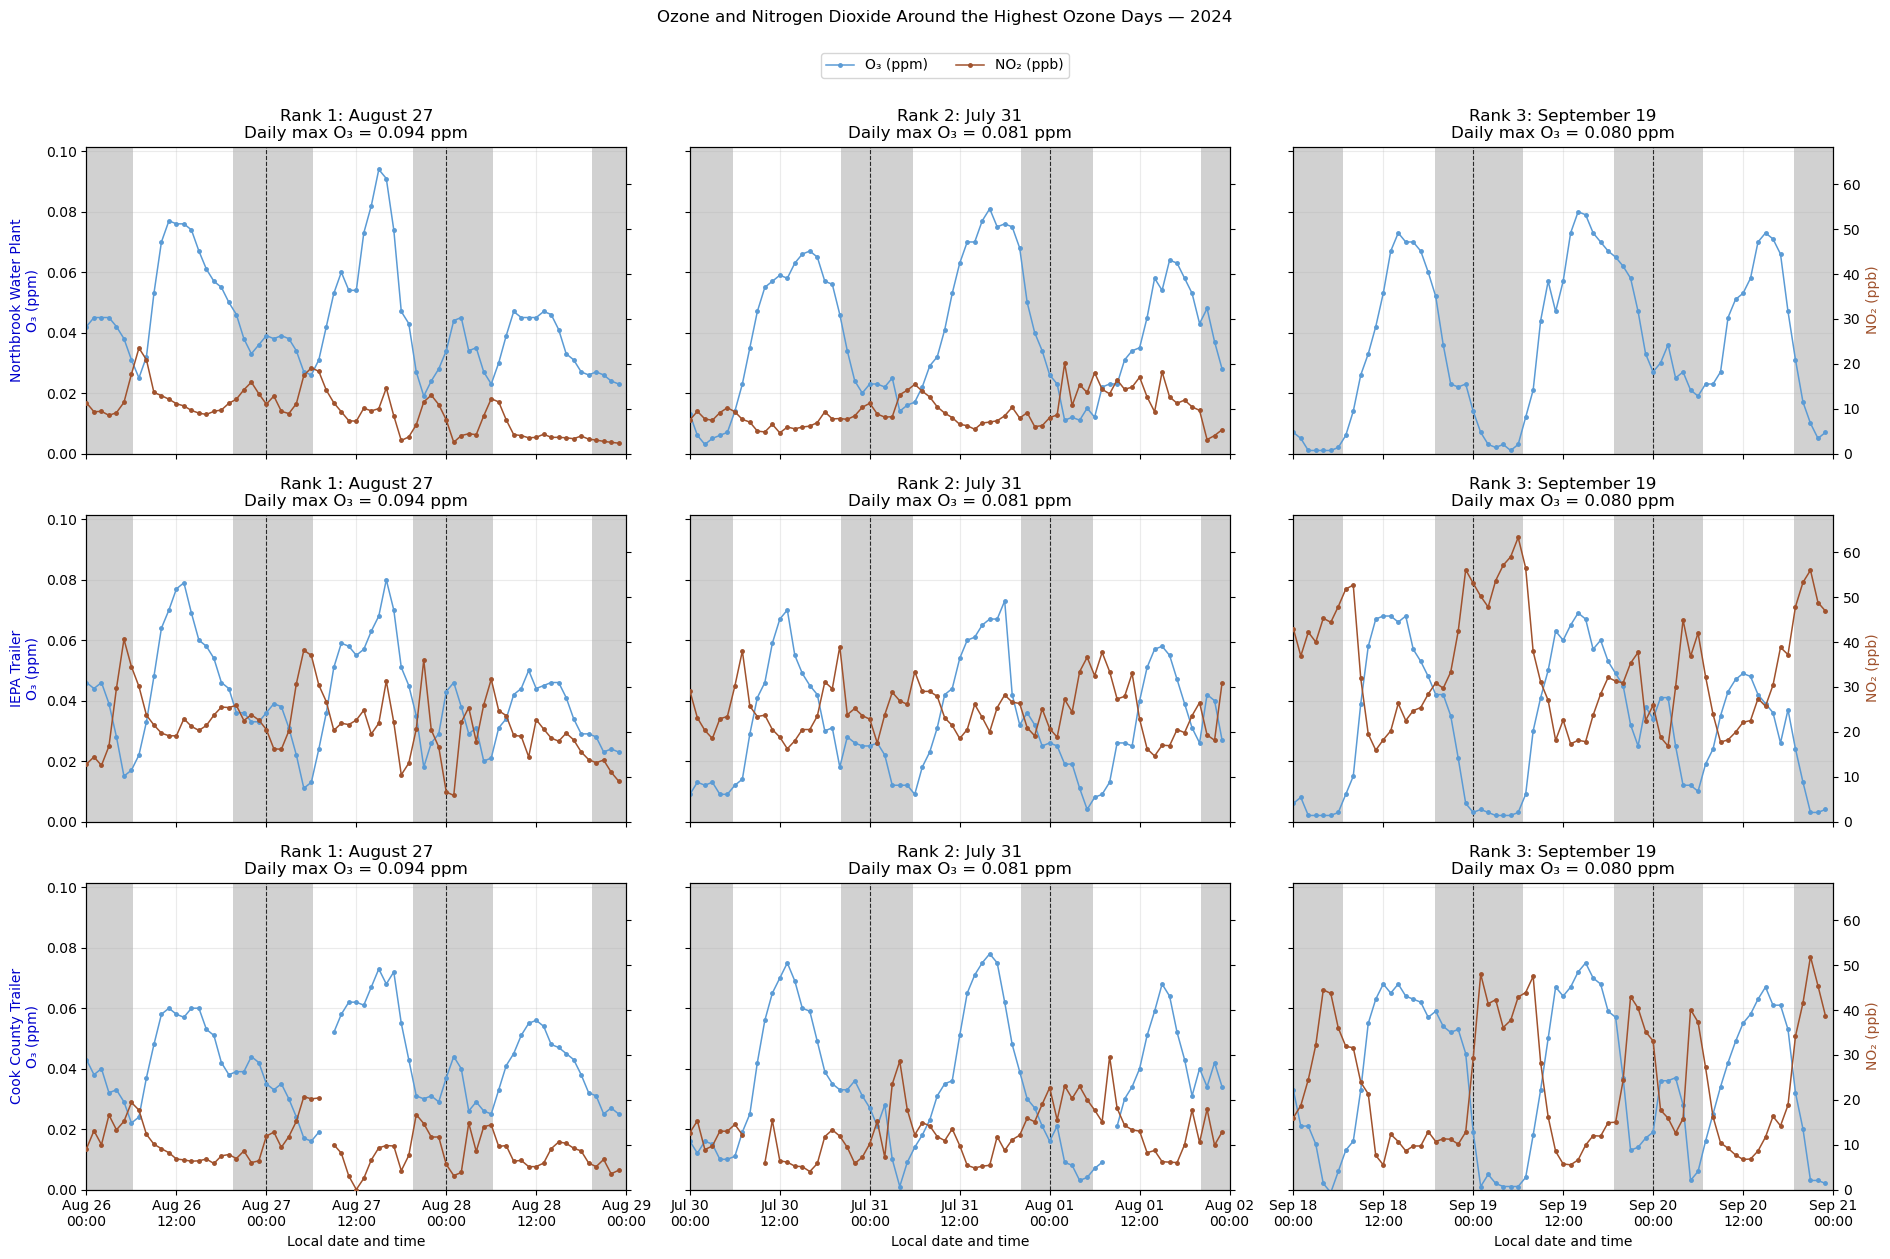

In [19]:
fig, axes = plt.subplots(
    nrows=len(EVENT_STATIONS),
    ncols=3,
    figsize=(19, 12),
)

ozone_line = None
no2_line = None

for row, station_key in enumerate(EVENT_STATIONS):
    station_name = STATIONS[station_key]["name"]
    top_days = top_three_ozone_days[station_key]

    for column, (_, top_day) in enumerate(top_days.iterrows()):
        ax_ozone = axes[row, column]
        ax_no2 = ax_ozone.twinx()

        peak_date = top_day["date_local"]
        window_start, peak_day_start, window_end = (
            three_day_event_window(peak_date)
        )
        peak_day_end = peak_day_start + pd.Timedelta(days=1)

        ozone_window = select_time_window(
            ozone_hourly[station_key],
            window_start,
            window_end,
        )
        no2_window = select_time_window(
            nitrogen_dioxide_hourly[station_key],
            window_start,
            window_end,
        )

        for box in nighttime_boxes(
            window_start.to_pydatetime(),
            window_end.to_pydatetime(),
            event_ozone_y_max,
            NORTHBROOK_LATITUDE,
            NORTHBROOK_LONGITUDE,
            CHICAGO_TIME,
        ):
            ax_ozone.add_patch(box)

        ozone_line = ax_ozone.plot(
            ozone_window["datetime_local"],
            ozone_window["sample_measurement"],
            color=OZONE_COLOR,
            marker="o",
            markersize=2.5,
            linewidth=1.1,
            label=f"{o3.symbol} ({o3.units})",
            zorder=3,
        )[0]

        no2_line = ax_no2.plot(
            no2_window["datetime_local"],
            no2_window["sample_measurement"],
            color=NO2_COLOR,
            marker="o",
            markersize=2.5,
            linewidth=1.1,
            label=f"{no2.symbol} ({no2.units})",
            zorder=3,
        )[0]

        # Bracket the ranked ozone day within the three-day window.
        ax_ozone.axvline(
            peak_day_start,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.8,
            zorder=2,
        )
        ax_ozone.axvline(
            peak_day_end,
            color="black",
            linestyle="--",
            linewidth=0.8,
            alpha=0.8,
            zorder=2,
        )

        ax_ozone.set_xlim(window_start, window_end)
        ax_ozone.set_ylim(0, event_ozone_y_max)
        ax_no2.set_ylim(0, event_no2_y_max)

        ax_ozone.xaxis.set_major_locator(
            mdates.HourLocator(byhour=[0, 12])
        )
        ax_ozone.xaxis.set_major_formatter(
            mdates.DateFormatter("%b %d\n%H:%M")
        )

        rank = column + 1
        maximum_ozone = top_day["first_max_value"]

        ax_ozone.set_title(
            f"Rank {rank}: {peak_date:%B %d}\n"
            f"Daily max {o3.symbol} = {maximum_ozone:.3f} {o3.units}"
        )
        ax_ozone.grid(alpha=0.25)

        if column == 0:
            ax_ozone.set_ylabel(
                f"{station_name}\n{o3.symbol} ({o3.units})",
                color="mediumblue",
            )
        else:
            ax_ozone.tick_params(axis="y", labelleft=False)

        if column == 2:
            ax_no2.set_ylabel(
                f"{no2.symbol} ({no2.units})",
                color=NO2_COLOR,
            )
        else:
            ax_no2.tick_params(axis="y", labelright=False)

        if row == len(EVENT_STATIONS) - 1:
            ax_ozone.set_xlabel("Local date and time")
        else:
            ax_ozone.tick_params(axis="x", labelbottom=False)

fig.legend(
    handles=[ozone_line, no2_line],
    loc="upper center",
    ncol=2,
    bbox_to_anchor=(0.5, 1.015),
)

fig.suptitle(
    f"Ozone and Nitrogen Dioxide Around the Highest Ozone Days — {YEAR}",
    y=1.045,
)
fig.tight_layout()

save_figure(
    fig,
    f"aqs_ozone_no2_high_ozone_events_cook_{YEAR}.png",
)

plt.show()

In [20]:
# AQS parameter codes for the common met variables.
PAMS_START_DT = dt.datetime(YEAR, 6, 1)
PAMS_END_DT = dt.datetime(YEAR, 8, 31)

MET_PARAMS = {
    "61301": "Mixing Height",
    "62101": "Outdoor Temperature",
    "61103": "Wind Speed - Resultant",
    "61104": "Wind Direction - Resultant",
    "61101": "Wind Speed (scalar)",
    "61102": "Wind Direction (scalar)",
    "64101": "Barometric Pressure",
    "62201": "Relative Humidity",
    "63301": "Solar Radiation",
    "63302": "UV Radiation",
    "63305": "Net Radiation",
    "63303": "Precipitation",
}

### Probing Northbrook for meteorological data

In [21]:
# Northbrook meteorological parameters for the lake-breeze diagnostic.
# (Codes are AQS parameter codes; not in aqs_codes, so named here.)
NORTHBROOK_MET_CODES = {
    "62101": "Outdoor Temperature",
    "61103": "Wind Speed - Resultant",
    "61104": "Wind Direction - Resultant",
    "63301": "Solar Radiation",
    "63302": "UV Radiation",
}


def download_northbrook_met(parameter_code, parameter_name):
    """Download one year of hourly Northbrook data for one met parameter."""
    station = STATIONS["Northbrook"]

    data = aqs.bysite.sampledata(
        parameter=parameter_code,
        bdate=START_DT,
        edate=END_DT,
        stateFIPS=STATE_FIPS,
        countycode=COUNTY_FIPS,
        sitenum=station["site_number"],
    )

    data = wrangle_aqs_timeseries(
        data,
        name=f"{station['name']} {parameter_name}",
    )

    hourly = data.loc[data["sample_duration"].eq("1 HOUR")].copy()
    if hourly.empty:
        raise ValueError(
            f"No 1-hour {parameter_name} data for Northbrook in {YEAR}."
        )

    return hourly.sort_values("datetime_local").reset_index(drop=True)


northbrook_met = {}

for code, name in NORTHBROOK_MET_CODES.items():
    print(f"Downloading {name}: Northbrook")
    northbrook_met[code] = download_northbrook_met(code, name)

# Units seen (verify wind is m/s vs knots, temp degF vs degC before trusting
# the size legend and axis labels below).
for code, name in NORTHBROOK_MET_CODES.items():
    units = northbrook_met[code]["units_of_measure"].dropna().unique()
    print(f"{code} {name}: units = {list(units)}")

62101 Outdoor Temperature: units = ['Degrees Fahrenheit']
61103 Wind Speed - Resultant: units = ['Knots']
61104 Wind Direction - Resultant: units = ['Degrees Compass']
63301 Solar Radiation: units = ['Langleys/minute']
63302 UV Radiation: units = ['Langleys/minute']


## Northbrook Ozone and MET

Saved figures/aqs/aqs_northbrook_lake_breeze_events_2024.png


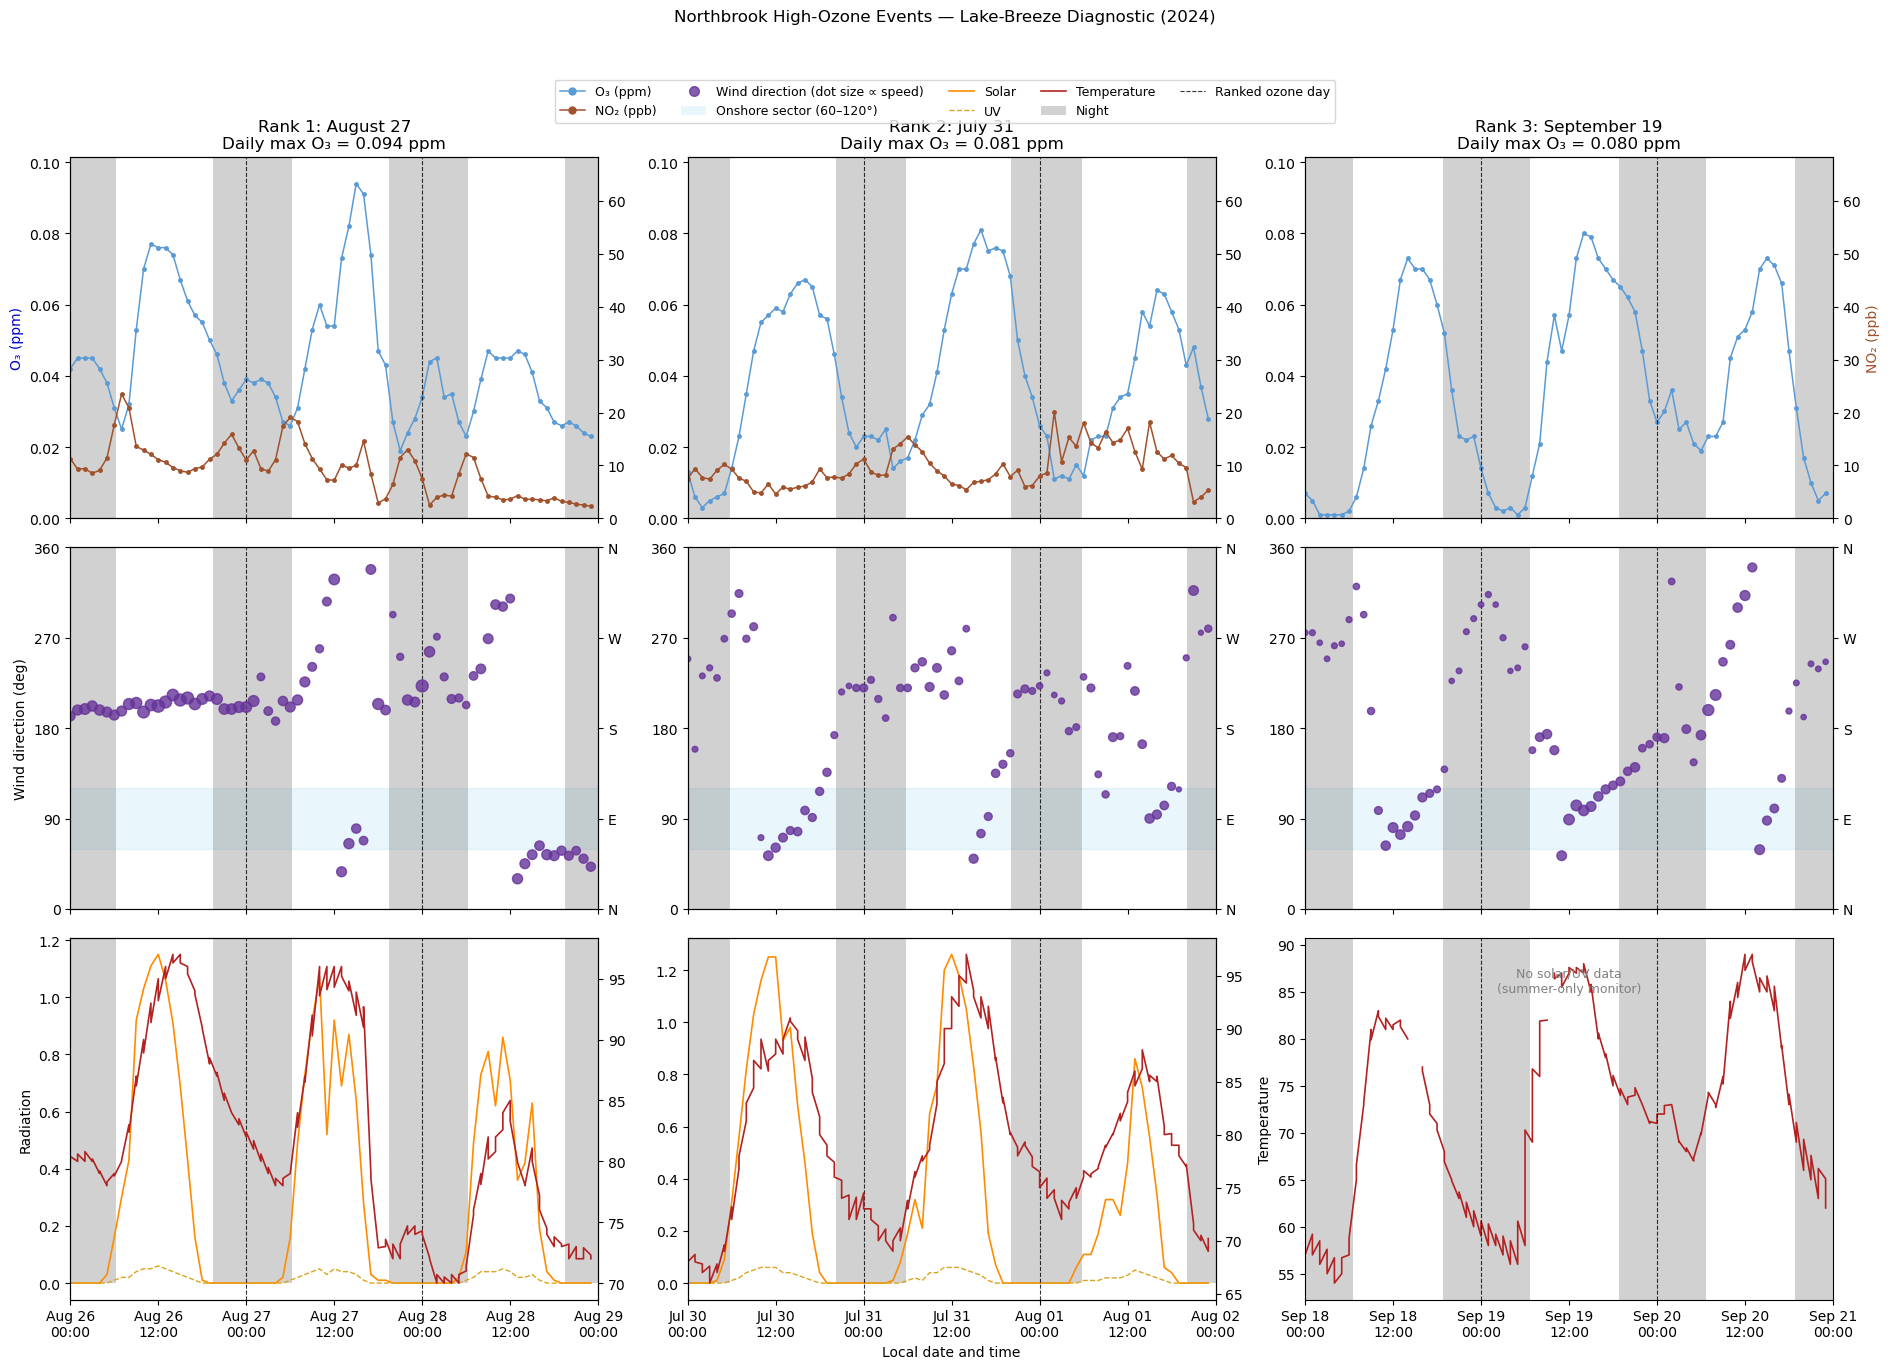

In [22]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

NORTHBROOK_ONSHORE = (60, 120)  # ENE-ESE lake-breeze sector for this site
WSPD_CODE, WDIR_CODE = "61103", "61104"
TEMP_CODE, SOLAR_CODE, UV_CODE = "62101", "63301", "63302"

# Marker-area scaling for wind speed: area proportional to speed, with a floor
# so calm dots stay visible. Tune SIZE_REF to the data's max speed if needed.
SIZE_FLOOR, SIZE_GAIN = 12, 9  # area = SIZE_FLOOR + SIZE_GAIN * speed


northbrook_top_three = ozone_daily_1hr["Northbrook"].head(3).copy()


def met_window(code, start_dt, end_dt):
    """Event-window slice of a Northbrook met parameter, local time."""
    return select_time_window(northbrook_met[code], start_dt, end_dt)


fig, axes = plt.subplots(
    nrows=3,
    ncols=3,
    figsize=(19, 13),
    sharex="col",
)

for column, (_, top_day) in enumerate(northbrook_top_three.iterrows()):
    peak_date = top_day["date_local"]
    window_start, peak_day_start, window_end = three_day_event_window(peak_date)
    peak_day_end = peak_day_start + pd.Timedelta(days=1)

    ax_o3 = axes[0, column]
    ax_wind = axes[1, column]
    ax_rad = axes[2, column]

    # --- Row 1: ozone + NO2 ---
    ax_no2 = ax_o3.twinx()
    o3_w = select_time_window(ozone_hourly["Northbrook"], window_start, window_end)
    no2_w = select_time_window(
        nitrogen_dioxide_hourly["Northbrook"], window_start, window_end
    )
    ax_o3.plot(o3_w["datetime_local"], o3_w["sample_measurement"],
               color=OZONE_COLOR, marker="o", markersize=2.5, linewidth=1.1)
    ax_no2.plot(no2_w["datetime_local"], no2_w["sample_measurement"],
                color=NO2_COLOR, marker="o", markersize=2.5, linewidth=1.1)
    ax_o3.set_ylim(0, event_ozone_y_max)
    ax_no2.set_ylim(0, event_no2_y_max)
    if column == 0:
        ax_o3.set_ylabel(f"{o3.symbol} ({o3.units})", color="mediumblue")
    if column == 2:
        ax_no2.set_ylabel(f"{no2.symbol} ({no2.units})", color=NO2_COLOR)

    # --- Row 2: wind direction, dot size = speed, onshore band ---
    wdir = met_window(WDIR_CODE, window_start, window_end)
    wspd = met_window(WSPD_CODE, window_start, window_end).set_index("datetime_local")
    speed_at = wspd["sample_measurement"].reindex(wdir["datetime_local"]).to_numpy()
    sizes = SIZE_FLOOR + SIZE_GAIN * pd.Series(speed_at).fillna(0).to_numpy()

    ax_wind.axhspan(*NORTHBROOK_ONSHORE, color="skyblue", alpha=0.18, zorder=0)
    ax_wind.scatter(wdir["datetime_local"], wdir["sample_measurement"],
                    s=sizes, color="rebeccapurple", alpha=0.8, zorder=3)
    ax_wind.set_ylim(0, 360)
    ax_wind.set_yticks([0, 90, 180, 270, 360])
    if column == 0:
        ax_wind.set_ylabel("Wind direction (deg)")
    # Right-side compass labels (top == bottom == N).
    ax_wind_r = ax_wind.twinx()
    ax_wind_r.set_ylim(0, 360)
    ax_wind_r.set_yticks([0, 90, 180, 270, 360])
    ax_wind_r.set_yticklabels(["N", "E", "S", "W", "N"])

    # --- Row 3: solar + UV (left), temperature (right) ---
# --- Row 3: solar + UV (left), temperature (right) ---
    solar = met_window(SOLAR_CODE, window_start, window_end)
    uv = met_window(UV_CODE, window_start, window_end)
    temp = met_window(TEMP_CODE, window_start, window_end)

    has_radiation = (
        solar["sample_measurement"].notna().any()
        or uv["sample_measurement"].notna().any()
    )

    if has_radiation:
        ax_temp = ax_rad.twinx()
        ax_rad.plot(solar["datetime_local"], solar["sample_measurement"],
                    color="darkorange", linewidth=1.2, label="Solar")
        ax_rad.plot(uv["datetime_local"], uv["sample_measurement"],
                    color="goldenrod", linewidth=1.0, linestyle="--", label="UV")
        ax_temp.plot(temp["datetime_local"], temp["sample_measurement"],
                     color="firebrick", linewidth=1.2, label="Temp")
        if column == 0:
            ax_rad.set_ylabel("Radiation")
        if column == 2:
            ax_temp.set_ylabel("Temperature")
    else:
        # No radiation this window (Northbrook solar/UV are summer-only,
        # ~Jun-Aug). Plot temperature on the primary axis so it scales
        # correctly, and label the gap rather than showing an empty scale.
        ax_temp = ax_rad  # temperature owns the subplot
        ax_rad.plot(temp["datetime_local"], temp["sample_measurement"],
                    color="firebrick", linewidth=1.2, label="Temp")
        ax_rad.set_ylabel("Temperature")
        ax_rad.annotate(
            "No solar/UV data\n(summer-only monitor)",
            xy=(0.5, 0.92), xycoords="axes fraction",
            ha="center", va="top", fontsize=9, color="gray",
        )
            
    # Shared per-column decoration: nighttime, day brackets, x range/format.
    for ax in (ax_o3, ax_wind, ax_rad):
        for box in nighttime_boxes(window_start.to_pydatetime(),
                                   window_end.to_pydatetime(),
                                   ax.get_ylim()[1],
                                   NORTHBROOK_LATITUDE, NORTHBROOK_LONGITUDE,
                                   CHICAGO_TIME):
            ax.add_patch(box)
        ax.axvline(peak_day_start, color="black", ls="--", lw=0.8, alpha=0.8)
        ax.axvline(peak_day_end, color="black", ls="--", lw=0.8, alpha=0.8)
        ax.set_xlim(window_start, window_end)

    ax_rad.xaxis.set_major_locator(mdates.HourLocator(byhour=[0, 12]))
    ax_rad.xaxis.set_major_formatter(mdates.DateFormatter("%b %d\n%H:%M"))
    ax_o3.set_title(
        f"Rank {column + 1}: {peak_date:%B %d}\n"
        f"Daily max {o3.symbol} = {top_day['first_max_value']:.3f} {o3.units}"
    )

# Figure-level legend covering every element across the three rows. Proxy
# artists are used because these live on different axes/rows.
legend_handles = [
    Line2D([0], [0], color=OZONE_COLOR, marker="o", markersize=5,
           linewidth=1.1, label=f"{o3.symbol} ({o3.units})"),
    Line2D([0], [0], color=NO2_COLOR, marker="o", markersize=5,
           linewidth=1.1, label=f"{no2.symbol} ({no2.units})"),
    Line2D([0], [0], marker="o", markersize=7, linestyle="none",
           color="rebeccapurple", alpha=0.8,
           label="Wind direction (dot size ∝ speed)"),
    Patch(facecolor="skyblue", alpha=0.18, label="Onshore sector (60–120°)"),
    Line2D([0], [0], color="darkorange", linewidth=1.2, label="Solar"),
    Line2D([0], [0], color="goldenrod", linewidth=1.0, linestyle="--",
           label="UV"),
    Line2D([0], [0], color="firebrick", linewidth=1.2, label="Temperature"),
    Patch(facecolor="dimgray", alpha=0.30, label="Night"),
    Line2D([0], [0], color="black", linestyle="--", linewidth=0.8, alpha=0.8,
           label="Ranked ozone day"),
]

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=5,
    bbox_to_anchor=(0.5, 1.00),
    fontsize=9,
)

axes[2, 1].set_xlabel("Local date and time")
fig.suptitle(
    f"Northbrook High-Ozone Events — Lake-Breeze Diagnostic ({YEAR})", y=1.05
)
fig.tight_layout()
save_figure(fig, f"aqs_northbrook_lake_breeze_events_{YEAR}.png")
plt.show()

### Wind Roses

In [ ]:
# Wind-rose and pollutant-rose plotting. Adds a dependency (windrose).
# If already installed, the pip line is a no-op.
import sys
!{sys.executable} -m pip install --quiet windrose --break-system-packages

import numpy as np
from windrose import WindroseAxes

In [ ]:
# Unified rose conventions, so wind/ozone/NO2 and every site read the same way.
# CONVENTION: dark = HIGH everywhere (high wind speed, high ozone, high NO2).
WIND_CMAP = plt.cm.viridis_r     # reversed: dark = strong wind
OZONE_CMAP = plt.cm.YlGnBu       # already light->dark = low->high
NO2_CMAP = plt.cm.YlOrRd         # already light->dark = low->high

# Rose geometry and bin edges (restored — these are used throughout the rose
# cells and the shared_radial_ticks helper below).
NSECTOR = 16
CALM_LIMIT_KN = 2                     # drop sub-2-kn hours from wind roses
WIND_SPEED_BINS = [2, 4, 8, 12, 16]   # knots (bins must start at calm_limit)
NO2_ROSE_BINS = [0, 5, 10, 20, 30]    # ppb

# Ozone bins spread across the real ppm distribution, with legible edges.
OZONE_ROSE_BINS = [0.0, 0.025, 0.040, 0.055, 0.070]   # ppm
# (NO2 bins unchanged: 0/5/10/20/30 ppb)


def shared_radial_ticks(frame, dir_col, var_col, periods, nsector=NSECTOR,
                        calm_limit=None, n_rings=4):
    """Shared radial ceiling (%) and explicit tick list across period subsets.

    Returns (rmax, yticks) so every panel draws identical rings. windrose
    normes each panel to its own data, so we must set both the limit AND the
    ticks explicitly or the ring *labels* still differ panel to panel.
    """
    peak = 0.0
    for hours in periods:
        sub = frame[frame.index.hour.isin(hours)].dropna(subset=[var_col, dir_col])
        if calm_limit is not None:
            sub = sub[sub[var_col] >= calm_limit]
        if sub.empty:
            continue
        sector = ((sub[dir_col] % 360) // (360 / nsector)).astype(int)
        counts = np.bincount(sector, minlength=nsector)
        if counts.sum():
            peak = max(peak, 100.0 * counts.max() / counts.sum())
    rmax = np.ceil(peak / 2.0) * 2.0          # round up to nearest 2%
    yticks = list(np.linspace(0, rmax, n_rings + 1))[1:]   # drop the 0 ring
    return rmax, yticks

In [ ]:
# Rebuild the paired ozone-season frame the roses are built from.
# (This construction cell was lost; ozone_hourly, nitrogen_dioxide_hourly, and
# northbrook_met all still exist, so we reassemble from them.)
WSPD_CODE, WDIR_CODE = "61103", "61104"
OZONE_SEASON_MONTHS = range(4, 10)   # April-September


def _hourly_series(frame, name):
    """A datetime_local-indexed Series of sample_measurement, renamed."""
    return frame.set_index("datetime_local")["sample_measurement"].rename(name)


# Northbrook wind is already hourly, datetime_local-indexed, in northbrook_met.
_wind = northbrook_met[WSPD_CODE].set_index("datetime_local")["sample_measurement"]
_wdir = northbrook_met[WDIR_CODE].set_index("datetime_local")["sample_measurement"]

rose_frame = pd.concat(
    [
        _hourly_series(ozone_hourly["Northbrook"], "o3"),
        _hourly_series(nitrogen_dioxide_hourly["Northbrook"], "no2"),
        _wind.rename("wspd"),
        _wdir.rename("wdir"),
    ],
    axis=1,
    join="inner",
).dropna(subset=["wdir"])

# Restrict to ozone season (matches the rose figures' scope).
rose_frame = rose_frame[rose_frame.index.month.isin(OZONE_SEASON_MONTHS)].copy()

print(f"rose_frame rebuilt: {len(rose_frame):,} paired ozone-season hours")
print(f"  o3  ppm: {rose_frame['o3'].min():.3f} .. {rose_frame['o3'].max():.3f}")
print(f"  no2 ppb: {rose_frame['no2'].min():.1f} .. {rose_frame['no2'].max():.1f}")
print(f"  wind kn: {rose_frame['wspd'].min():.1f} .. {rose_frame['wspd'].max():.1f}")

rose_frame rebuilt: 2,153 paired ozone-season hours
  o3  ppm: 0.000 .. 0.094
  no2 ppb: 1.2 .. 66.1
  wind kn: 0.0 .. 11.7


Tallest petal across panels: 14.4%  ->  rmax 16%
Saved figures/aqs/aqs_northbrook_wind_rose_timeofday_2024.png


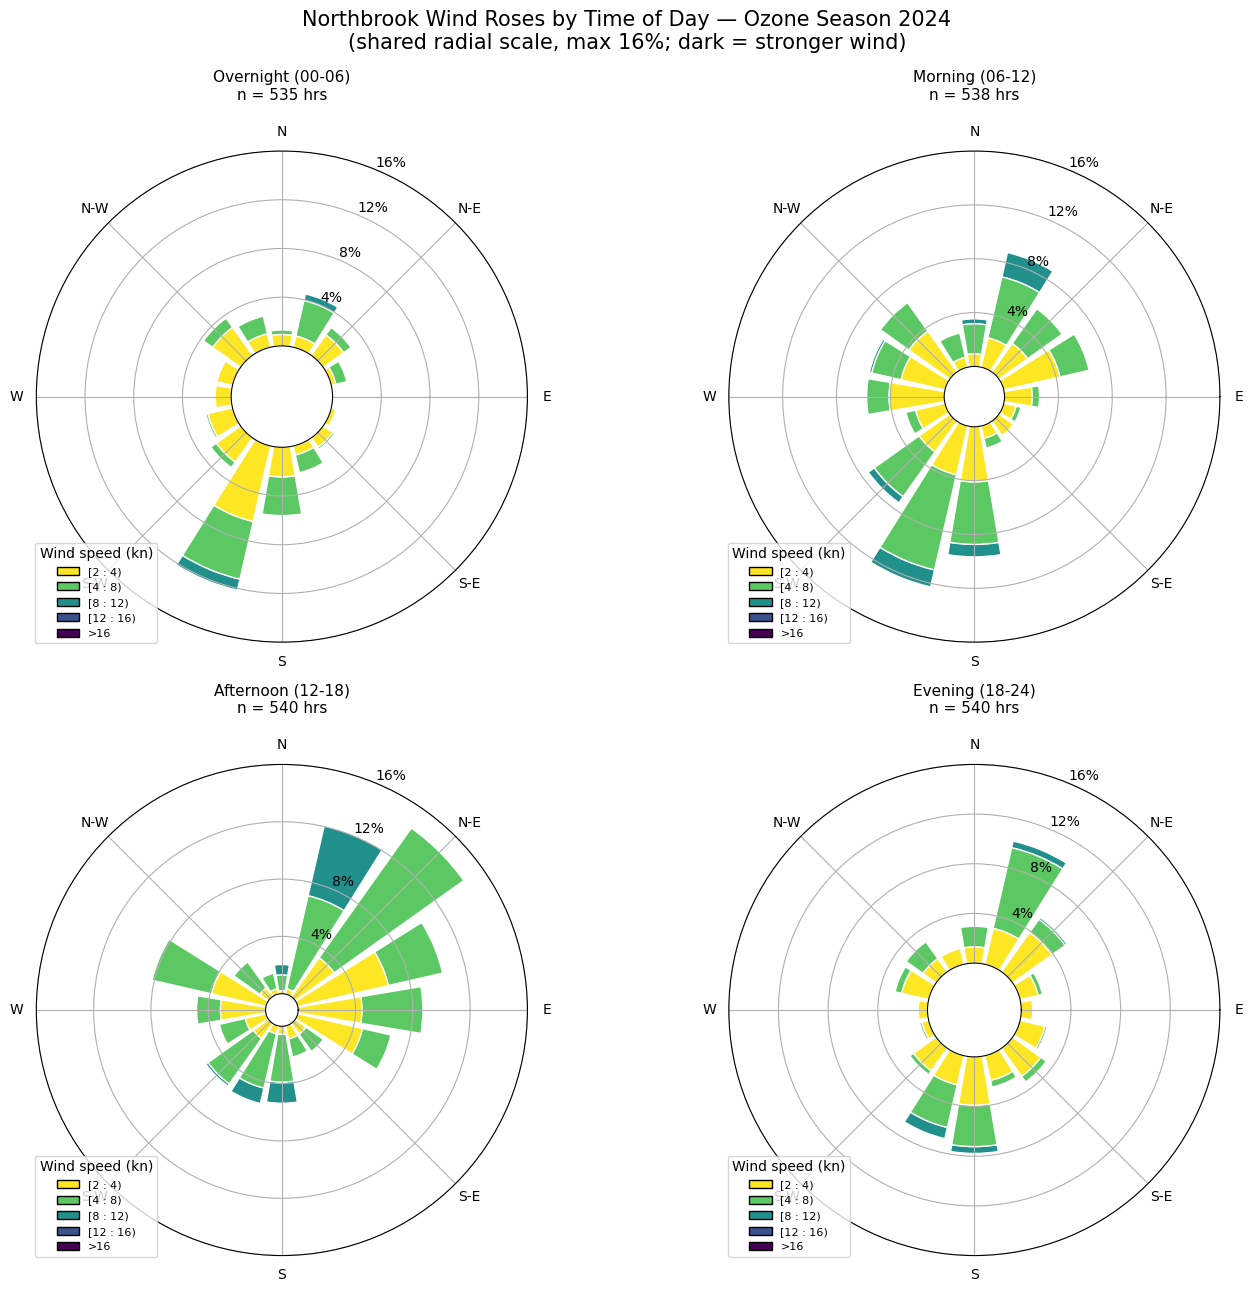

In [ ]:
TIME_OF_DAY = {
    "Overnight (00-06)": range(0, 6),
    "Morning (06-12)": range(6, 12),
    "Afternoon (12-18)": range(12, 18),
    "Evening (18-24)": range(18, 24),
}
tod_periods = list(TIME_OF_DAY.items())

fig = plt.figure(figsize=(14, 13))
rose_axes = []
panel_peaks = []

# Pass 1: draw each rose, record its true tallest petal from windrose's table.
for i, (label, hours) in enumerate(tod_periods, start=1):
    period = rose_frame[rose_frame.index.hour.isin(hours)].dropna(subset=["wspd"])
    ax = fig.add_subplot(2, 2, i, projection="windrose")
    ax.bar(
        period["wdir"].to_numpy(), period["wspd"].to_numpy(),
        bins=WIND_SPEED_BINS, nsector=NSECTOR, normed=True,
        opening=0.85, edgecolor="white", cmap=WIND_CMAP,
        calm_limit=CALM_LIMIT_KN,
    )
    # windrose stores the plotted table: rows = speed bins, cols = sectors.
    stacked = ax._info["table"].sum(axis=0)   # total % per direction sector
    panel_peaks.append(stacked.max())
    ax.set_title(f"{label}\nn = {len(period):,} hrs", fontsize=11, pad=18)
    ax.set_legend(title="Wind speed (kn)", loc="lower left",
                  fontsize=8, decimal_places=0)
    rose_axes.append(ax)

# Shared ceiling: the tallest petal across all panels, rounded up to 2%,
# with a hair of headroom so the biggest petal doesn't touch the rim.
tod_rmax = np.ceil(max(panel_peaks) / 2.0) * 2.0
tod_yticks = list(np.linspace(0, tod_rmax, 5))[1:]

# Pass 2: apply the shared scale to every panel.
for ax in rose_axes:
    ax.set_rmax(tod_rmax)
    ax.set_rgrids(tod_yticks, labels=[f"{t:.0f}%" for t in tod_yticks])

print(f"Tallest petal across panels: {max(panel_peaks):.1f}%  ->  rmax {tod_rmax:.0f}%")

fig.suptitle(
    f"Northbrook Wind Roses by Time of Day — Ozone Season {YEAR}\n"
    f"(shared radial scale, max {tod_rmax:.0f}%; dark = stronger wind)",
    fontsize=15, y=0.99,
)
fig.tight_layout()
save_figure(fig, f"aqs_northbrook_wind_rose_timeofday_{YEAR}.png")
plt.show()

Saved figures/aqs/aqs_northbrook_wind_ozone_no2_roses_2024.png


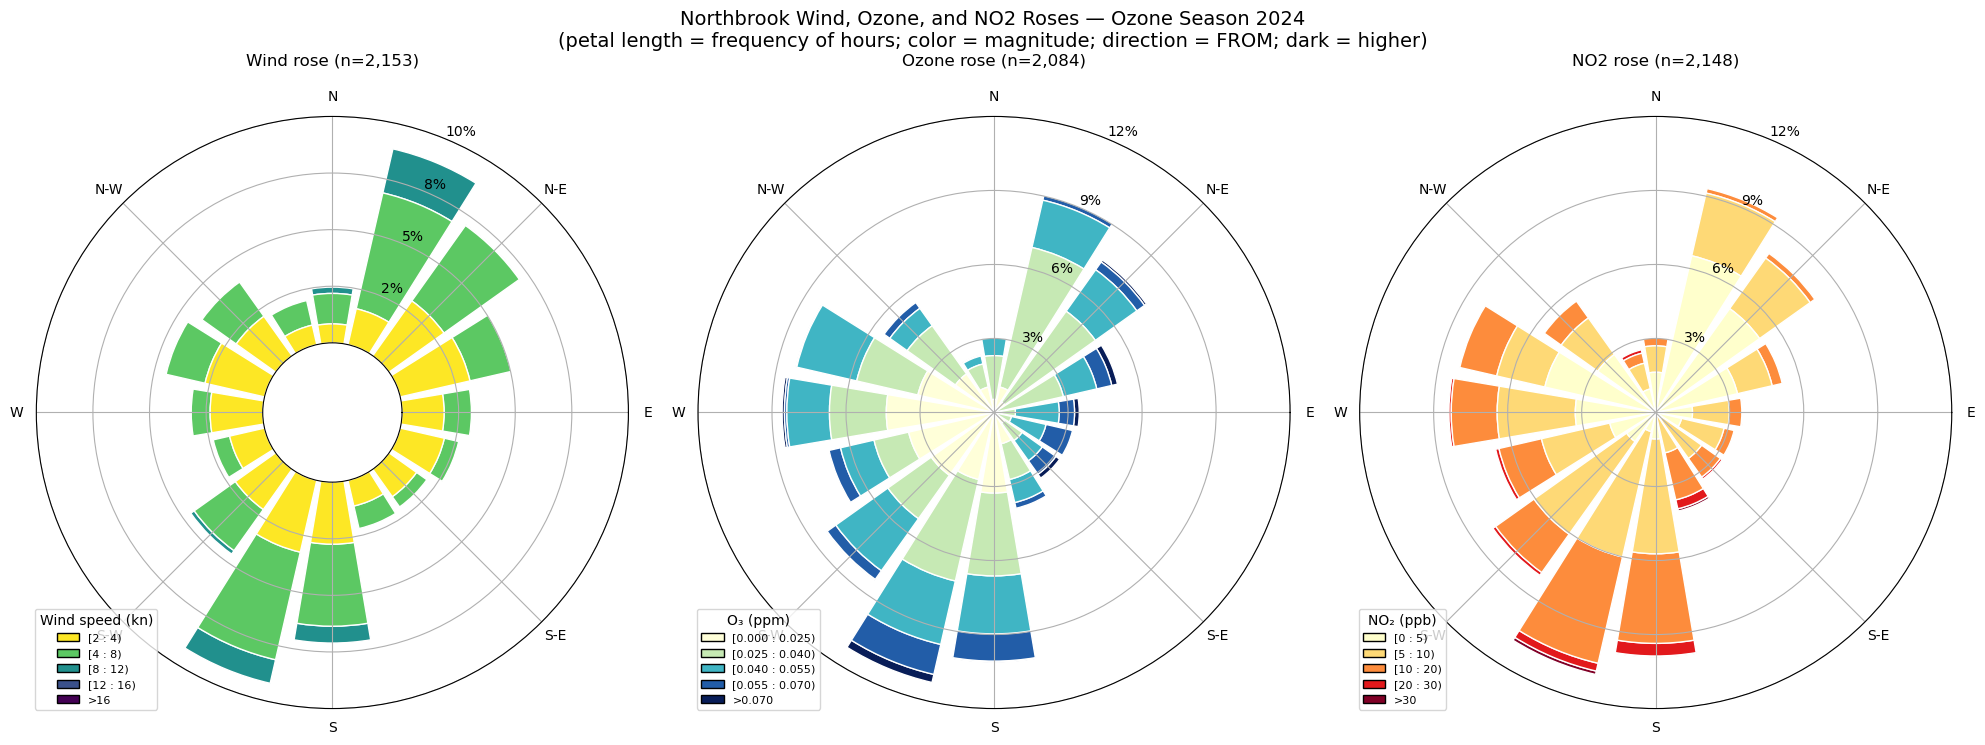

In [ ]:
fig = plt.figure(figsize=(20, 7))


def _freq_rose(subplot, dir_vals, var_vals, bins, cmap, title,
               legend_title, decimals, calm=None):
    ax = fig.add_subplot(1, 3, subplot, projection="windrose")
    ax.bar(dir_vals, var_vals, bins=bins, nsector=NSECTOR, normed=True,
           opening=0.85, edgecolor="white", cmap=cmap, calm_limit=calm)
    # Tighten the radial scale to this rose's own tallest petal so it fills
    # the circle. windrose stores the plotted table (speed/conc bins x sectors).
    peak = ax._info["table"].sum(axis=0).max()
    rmax = np.ceil(peak / 2.0) * 2.0
    yticks = list(np.linspace(0, rmax, 5))[1:]
    ax.set_rmax(rmax)
    ax.set_rgrids(yticks, labels=[f"{t:.0f}%" for t in yticks])
    ax.set_title(title, fontsize=12, pad=18)
    ax.set_legend(title=legend_title, loc="lower left", fontsize=8,
                  decimal_places=decimals)
    return ax


wind_ok = rose_frame.dropna(subset=["wspd"])
_freq_rose(1, wind_ok["wdir"].to_numpy(), wind_ok["wspd"].to_numpy(),
           WIND_SPEED_BINS, WIND_CMAP, f"Wind rose (n={len(wind_ok):,})",
           "Wind speed (kn)", 0, calm=CALM_LIMIT_KN)

o3_ok = rose_frame.dropna(subset=["o3"])
_freq_rose(2, o3_ok["wdir"].to_numpy(), o3_ok["o3"].to_numpy(),
           OZONE_ROSE_BINS, OZONE_CMAP, f"Ozone rose (n={len(o3_ok):,})",
           f"{o3.symbol} ({o3.units})", 3)

no2_ok = rose_frame.dropna(subset=["no2"])
_freq_rose(3, no2_ok["wdir"].to_numpy(), no2_ok["no2"].to_numpy(),
           NO2_ROSE_BINS, NO2_CMAP, f"NO2 rose (n={len(no2_ok):,})",
           f"{no2.symbol} ({no2.units})", 0)

fig.suptitle(
    f"Northbrook Wind, Ozone, and NO2 Roses — Ozone Season {YEAR}\n"
    "(petal length = frequency of hours; color = magnitude; direction = FROM; "
    "dark = higher)",
    fontsize=14, y=1.02,
)
fig.tight_layout()
save_figure(fig, f"aqs_northbrook_wind_ozone_no2_roses_{YEAR}.png")
plt.show()

Saved figures/aqs/aqs_northbrook_mean_concentration_roses_2024.png


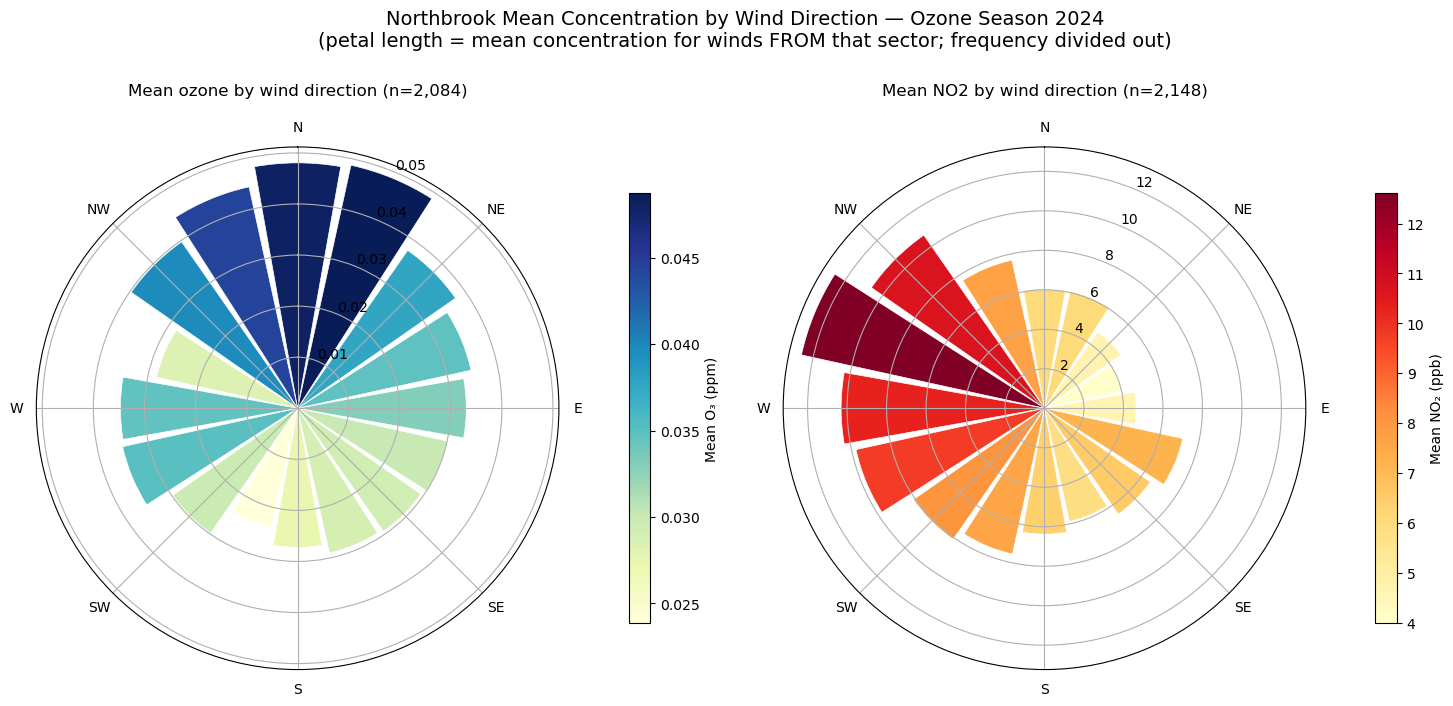

In [ ]:
def mean_concentration_rose(ax, wdir, values, cmap, title, cbar_label,
                            nsector=NSECTOR, min_count=5):
    """Polar bar rose where petal length = mean value per direction sector.

    Sectors with fewer than min_count hours are dropped (unreliable mean).
    Bars are colored by the same mean, so length and color both encode
    concentration (dark = higher).
    """
    df = pd.DataFrame({"wdir": wdir, "val": values}).dropna()
    sector = ((df["wdir"] % 360) // (360 / nsector)).astype(int)
    grp = df.groupby(sector)["val"]
    means = grp.mean().reindex(range(nsector))
    counts = grp.count().reindex(range(nsector)).fillna(0)
    means = means.where(counts >= min_count)   # NaN out thin sectors

    width = 2 * np.pi / nsector
    # Sector centers, N at top, clockwise (meteorological).
    theta = np.deg2rad(np.arange(nsector) * (360 / nsector))
    theta_plot = (np.pi / 2) - theta            # rotate so 0deg=N=up
    heights = means.to_numpy()

    norm = plt.Normalize(np.nanmin(heights), np.nanmax(heights))
    colors = cmap(norm(heights))

    ax.bar(theta_plot, np.nan_to_num(heights), width=width * 0.9,
           color=colors, edgecolor="white", linewidth=0.5)
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(["N", "NE", "E", "SE", "S", "SW", "W", "NW"])
    ax.set_title(title, fontsize=12, pad=18)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, pad=0.1, shrink=0.7)
    cbar.set_label(cbar_label)


fig, axes = plt.subplots(
    1, 2, figsize=(15, 7), subplot_kw={"projection": "polar"}
)

o3_ok = rose_frame.dropna(subset=["o3"])
mean_concentration_rose(
    axes[0], o3_ok["wdir"].to_numpy(), o3_ok["o3"].to_numpy(),
    OZONE_CMAP, f"Mean ozone by wind direction (n={len(o3_ok):,})",
    f"Mean {o3.symbol} ({o3.units})",
)

no2_ok = rose_frame.dropna(subset=["no2"])
mean_concentration_rose(
    axes[1], no2_ok["wdir"].to_numpy(), no2_ok["no2"].to_numpy(),
    NO2_CMAP, f"Mean NO2 by wind direction (n={len(no2_ok):,})",
    f"Mean {no2.symbol} ({no2.units})",
)

fig.suptitle(
    f"Northbrook Mean Concentration by Wind Direction — Ozone Season {YEAR}\n"
    "(petal length = mean concentration for winds FROM that sector; "
    "frequency divided out)",
    fontsize=14, y=1.03,
)
fig.tight_layout()
save_figure(fig, f"aqs_northbrook_mean_concentration_roses_{YEAR}.png")
plt.show()

## Station Search

In [ ]:
# Which Cook County sites have the full O3 + NO2 + wind set (temp/rad a plus)?
SURVEY_PARAMS = {
    o3.code: "O3",
    no2.code: "NO2",
    "61103": "wind_spd",
    "61104": "wind_dir",
    "62101": "temp",
    "63301": "solar",
    "63302": "uv",
}

# One-week probe window (cheap) to test presence, not completeness.
SURVEY_START = dt.datetime(YEAR, 6, 1)
SURVEY_END = dt.datetime(YEAR, 6, 7)


def county_sites_with_param(param_code):
    """Site numbers in Cook County reporting a parameter in the probe week."""
    try:
        mon = aqs.bycounty.monitors(
            parameter=param_code,
            bdate=SURVEY_START,
            edate=SURVEY_END,
            stateFIPS=STATE_FIPS,
            countycode=COUNTY_FIPS,
        )
    except Exception as exc:  # noqa: BLE001
        print(f"  {param_code}: query error ({exc})")
        return {}
    if mon is None or mon.empty:
        return {}
    # site_number -> local site name (first non-null)
    out = {}
    for _, row in mon.iterrows():
        site = str(row.get("site_number", "")).zfill(4)
        name = row.get("local_site_name") or row.get("address") or ""
        out.setdefault(site, name)
    return out


coverage = {}   # site_number -> {param_label: True}
site_names = {}

for code, label in SURVEY_PARAMS.items():
    print(f"Scanning county for {label} ({code})...")
    sites = county_sites_with_param(code)
    for site, name in sites.items():
        coverage.setdefault(site, {})[label] = True
        site_names.setdefault(site, name)

# Build a presence table.
rows = []
for site in sorted(coverage):
    row = {"site": site, "name": site_names.get(site, "")[:32]}
    for label in SURVEY_PARAMS.values():
        row[label] = "Y" if coverage[site].get(label) else ""
    rows.append(row)

survey = pd.DataFrame(rows)

# Flag the ones that clear the bar: O3 + NO2 + both wind channels.
survey["rose_ready"] = (
    (survey["O3"] == "Y") & (survey["NO2"] == "Y")
    & (survey["wind_spd"] == "Y") & (survey["wind_dir"] == "Y")
)
display(survey)
print(f"\nSites with O3 + NO2 + wind: "
      f"{survey['rose_ready'].sum()} of {len(survey)}")

Scanning county for O3 (44201)...
Scanning county for NO2 (42602)...
Scanning county for wind_spd (61103)...
Scanning county for wind_dir (61104)...
Scanning county for temp (62101)...
Scanning county for solar (63301)...
Scanning county for uv (63302)...


,site,name,O3,NO2,wind_spd,wind_dir,temp,solar,uv,rose_ready
0,0001,VILLAGE GARAGE,Y,,,,,,,False
1,0032,SOUTH WATER FILTRATION PLANT,Y,,,,,,,False
2,0076,COM ED MAINTENANCE BLDG,Y,Y,,,,,,False
3,0119,Kingery Near Road #1,,Y,,,Y,,,False
4,0219,Kennedy Near Road 2,,Y,,,,,,False
5,1003,TAFT HS,Y,,,,,,,False
6,1016,VILLAGE HALL,,,,,Y,,,False
7,1601,COOK COUNTY TRAILER,Y,,,,,,,False
8,3103,IEPA TRAILER,Y,Y,,,Y,,,False
9,4002,COOK COUNTY TRAILER,Y,Y,,,,,,False



Sites with O3 + NO2 + wind: 1 of 13


## Suggested questions

- Do the highest ozone days occur at all four stations, or are some events more
  localized?
- At what local hour does ozone usually peak during the nine three-day event windows?
- Does NO₂ tend to rise before ozone, after ozone, or at the same time?
- How do the lakefront Evanston record and the three inland/trailer records
  differ?
- After changing `YEAR`, are the same seasonal and diurnal patterns still
  visible?
